In [1]:
# cell 0
import numpy as np
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import ParameterGrid
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cell 1
X = pd.read_parquet("/kaggle/input/anomaly-data/features_v1.parquet")

# Drop identifiers
X = X.drop(columns=["CLM_ID", "DESYNPUF_ID"], errors="ignore")

# Cyclical encoding
X["month_sin"] = np.sin(2 * np.pi * X["month"] / 12)
X["month_cos"] = np.cos(2 * np.pi * X["month"] / 12)
X["dow_sin"]   = np.sin(2 * np.pi * X["day_of_week"] / 7)
X["dow_cos"]   = np.cos(2 * np.pi * X["day_of_week"] / 7)

X = X.drop(columns=["month", "day_of_week", "quarter"], errors="ignore")

X = X.fillna(0)

In [3]:
X.head()

,log_payment,payment_zscore,high_cost_flag,zero_payment_flag,claim_duration,weekend_flag,procedure_count,total_code_count,provider_claim_volume,provider_avg_payment,high_volume_provider_flag,month_sin,month_cos,dow_sin,dow_cos
0,3.713572,-0.427195,0,0,0,0,48,59,112,322.857143,1,5.000000e-01,-0.866025,0.974928,-0.222521
1,3.931826,-0.409369,0,0,0,0,48,59,8,166.250000,0,8.660254e-01,-0.500000,0.974928,-0.222521
2,4.510860,-0.338063,0,0,0,1,48,59,149,296.442953,1,-8.660254e-01,-0.500000,-0.781831,0.623490
3,5.707110,0.036291,0,0,0,1,48,59,76,267.368421,0,-2.449294e-16,1.000000,-0.781831,0.623490
4,5.303305,-0.141973,0,0,0,1,48,59,69,225.217391,0,5.000000e-01,0.866025,-0.781831,0.623490


In [4]:
# cell 2-scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
#cell 3- anomalies 3%
def top_frac_mask(scores, frac=0.03):
    k = int(len(scores) * frac)
    idx = np.argsort(scores)[-k:]
    mask = np.zeros(len(scores), dtype=bool)
    mask[idx] = True
    return mask

def top_frac_set(scores, frac=0.03):
    k = int(len(scores) * frac)
    return set(np.argsort(scores)[-k:])

def jaccard(a, b):
    return len(a & b) / len(a | b)

def stability_score(model_builder, X, frac=0.03, n_runs=5, sample_frac=0.8):
    overlaps = []
    prev = None
    
    for _ in range(n_runs):
        X_sub = resample(X, replace=False, n_samples=int(len(X) * sample_frac))
        model = model_builder()
        scores = -model.fit(X_sub).decision_function(X_sub)
        curr = top_frac_set(scores, frac)
        
        if prev is not None:
            overlaps.append(jaccard(prev, curr))
        prev = curr
    
    return float(np.mean(overlaps))

In [6]:
# cell 4 setting hyperparameters
if_grid = ParameterGrid({
    "n_estimators": [200, 400],
    "max_samples": [0.6, 0.8],
    "max_features": [0.5, 0.8],
    "contamination": [0.03]
})

svm_grid = ParameterGrid({
    "nu": [0.02, 0.03, 0.05],
    "gamma": ["scale", 0.1]
})

lof_grid = ParameterGrid({
    "n_neighbors": [20, 50, 100],
    "contamination": [0.03]
})

### Tuning models

In [7]:
# cell 5 - isolation forest tuning
if_results = []

for params in if_grid:
    def build_if():
        return IsolationForest(**params, random_state=42, n_jobs=-1)
    
    stab = stability_score(build_if, X_scaled, frac=0.03)
    if_results.append({**params, "stability": stab})

if_df = pd.DataFrame(if_results).sort_values("stability", ascending=False)
if_df.head()

,contamination,max_features,max_samples,n_estimators,stability
3,0.03,0.5,0.8,400,0.016020
1,0.03,0.5,0.6,400,0.015805
7,0.03,0.8,0.8,400,0.015374
0,0.03,0.5,0.6,200,0.015282
5,0.03,0.8,0.6,400,0.015192


### **cell 6 SVM tuning**
- SVM is tuned in quadratic time n^4. So, tuning the whole set is unfeasible. 

In [8]:
np.random.seed(42)
svm_idx = np.random.choice(len(X_scaled), 50000, replace=False)
X_svm_tune = X_scaled[svm_idx]

In [9]:
svm_results = []

for params in svm_grid:
    def build_svm():
        return OneClassSVM(kernel="rbf", **params)
    
    stab = stability_score(build_svm, X_svm_tune, frac=0.03)
    svm_results.append({**params, "stability": stab})

svm_df = pd.DataFrame(svm_results).sort_values("stability", ascending=False)
svm_df.head()

,gamma,nu,stability
2,scale,0.05,0.015880
0,scale,0.02,0.015879
4,0.1,0.03,0.015553
5,0.1,0.05,0.014695
1,scale,0.03,0.014483


In [10]:
best_svm_params = svm_df.iloc[0].drop("stability").to_dict()

best_svm = OneClassSVM(kernel="rbf", **best_svm_params)
best_svm.fit(X_scaled)  # try full data once

OneClassSVM(nu=0.05)

In [11]:
# cell 7 - LOF tuning
lof_results = []

for params in lof_grid:
    def build_lof():
        return LocalOutlierFactor(novelty=True, **params)
    
    stab = stability_score(build_lof, X_scaled, frac=0.03)
    lof_results.append({**params, "stability": stab})

lof_df = pd.DataFrame(lof_results).sort_values("stability", ascending=False)
lof_df.head()

,contamination,n_neighbors,stability
1,0.03,50,0.015557
0,0.03,20,0.015437
2,0.03,100,0.015343


In [12]:
# # cell 8 fitting each best model with full data. First convert integer parameters back to int
if_params = if_df.iloc[0].drop("stability").to_dict()
if_params["n_estimators"] = int(if_params["n_estimators"])
if_params["max_samples"] = float(if_params["max_samples"])  # stays float
if_params["max_features"] = float(if_params["max_features"])  # stays float

best_if  = IsolationForest(**if_params, random_state=42, n_jobs=-1)
best_svm = OneClassSVM(kernel="rbf", **svm_df.iloc[0].drop("stability").to_dict())
best_lof = LocalOutlierFactor(novelty=True, **lof_df.iloc[0].drop("stability").to_dict())

In [13]:
if_scores  = -best_if.fit(X_scaled).decision_function(X_scaled)

In [14]:
svm_scores = -best_svm.fit(X_scaled).decision_function(X_scaled)

In [15]:
lof_params = lof_df.iloc[0].drop("stability").to_dict()
lof_params["n_neighbors"] = int(lof_params["n_neighbors"])  # must be int

best_lof = LocalOutlierFactor(novelty=True, **lof_params)

In [16]:
lof_scores = -best_lof.fit(X_scaled).decision_function(X_scaled)

In [17]:
# cell 9 fair comparison between models with top 3
mask_if  = top_frac_mask(if_scores,  frac=0.03)
mask_svm = top_frac_mask(svm_scores, frac=0.03)
mask_lof = top_frac_mask(lof_scores, frac=0.03)

In [18]:
# cell 10 - Compare models (overlap + business signal)
def audit_stats(mask, X):
    return {
        "high_cost_rate": X.loc[mask, "high_cost_flag"].mean(),
        "zero_payment_rate": X.loc[mask, "zero_payment_flag"].mean(),
        "high_volume_provider_rate": X.loc[mask, "high_volume_provider_flag"].mean(),
        "avg_log_payment": X.loc[mask, "log_payment"].mean(),
        "count": int(mask.sum())
    }

audit_if  = audit_stats(mask_if,  X)
audit_svm = audit_stats(mask_svm, X)
audit_lof = audit_stats(mask_lof, X)

audit_if, audit_svm, audit_lof

({'high_cost_rate': np.float64(0.6649464831804281),
  'zero_payment_rate': np.float64(0.18979357798165136),
  'high_volume_provider_rate': np.float64(0.5538990825688074),
  'avg_log_payment': np.float64(6.085417079467795),
  'count': 5232},
 {'high_cost_rate': np.float64(0.4430428134556575),
  'zero_payment_rate': np.float64(0.12595565749235474),
  'high_volume_provider_rate': np.float64(0.4000382262996942),
  'avg_log_payment': np.float64(5.7817976072358785),
  'count': 5232},
 {'high_cost_rate': np.float64(0.10626911314984709),
  'zero_payment_rate': np.float64(0.06804281345565749),
  'high_volume_provider_rate': np.float64(0.5621177370030581),
  'avg_log_payment': np.float64(4.8397582799321786),
  'count': 5232})

In [19]:
# cell 11 - stability comparison
print("Isolation Forest stability:", if_df.iloc[0]["stability"])
print("OCSVM stability:", svm_df.iloc[0]["stability"])
print("LOF stability:", lof_df.iloc[0]["stability"])

Isolation Forest stability: 0.016020030869344823
OCSVM stability: 0.01588035922925745
LOF stability: 0.015557340276471333


In [20]:
# cell 12 - Consensus anomalies (high-confidence queue)
consensus_mask = mask_if & mask_svm
X_consensus = X.loc[consensus_mask]

print("Consensus anomalies (IF ∩ OCSVM):", X_consensus.shape[0])
X_consensus.head()

Consensus anomalies (IF ∩ OCSVM): 3012


,log_payment,payment_zscore,high_cost_flag,zero_payment_flag,claim_duration,weekend_flag,procedure_count,total_code_count,provider_claim_volume,provider_avg_payment,high_volume_provider_flag,month_sin,month_cos,dow_sin,dow_cos
49,7.003974,1.462402,0,0,0,0,48,59,2232,258.494624,1,-1.000000e+00,-1.836970e-16,0.781831,0.623490
113,7.378384,2.353721,1,0,20,1,48,59,39,492.051282,0,1.000000e+00,6.123234e-17,-0.781831,0.623490
114,8.101981,5.384206,1,0,20,1,48,59,32,607.500000,0,1.000000e+00,6.123234e-17,-0.974928,-0.222521
117,7.601402,3.066776,1,0,20,1,48,59,32,607.500000,0,1.224647e-16,-1.000000e+00,-0.781831,0.623490
119,7.863651,4.136359,1,0,20,0,48,59,32,607.500000,0,-5.000000e-01,-8.660254e-01,0.433884,-0.900969


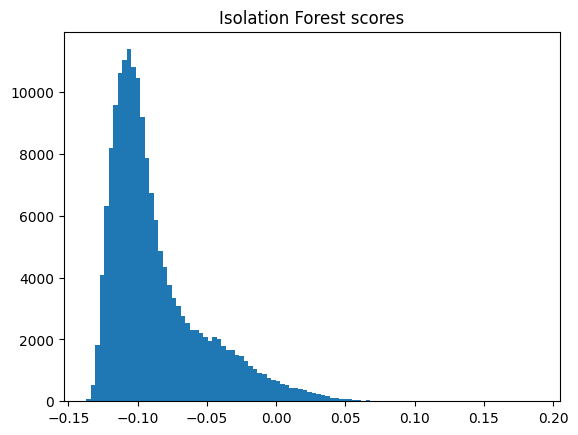

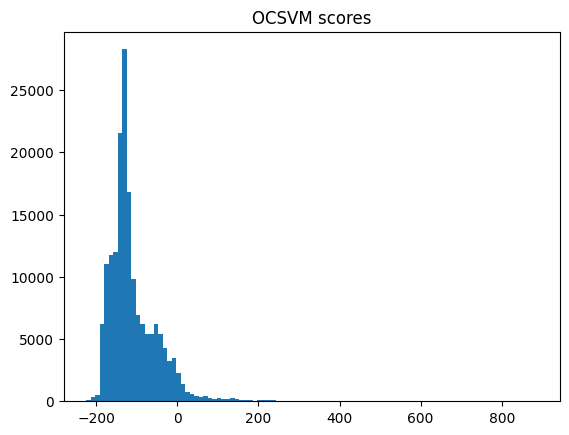

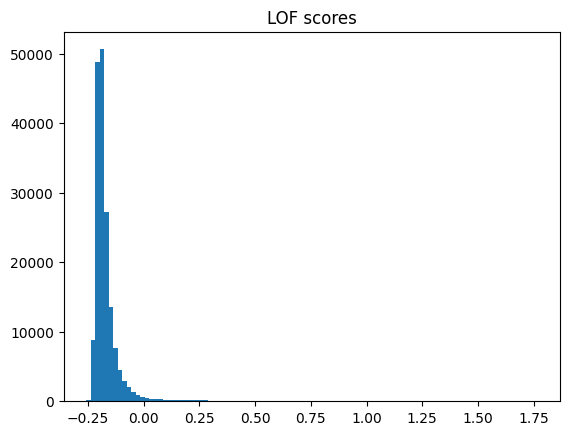

In [21]:
# cell 13 - score distribution sanity check
plt.hist(if_scores, bins=100); plt.title("Isolation Forest scores"); plt.show()
plt.hist(svm_scores, bins=100); plt.title("OCSVM scores"); plt.show()
plt.hist(lof_scores, bins=100); plt.title("LOF scores"); plt.show()

In [22]:
import os
output_dir = "/kaggle/working/thesis_results"
os.makedirs(output_dir, exist_ok=True)

# Audit stats function
def audit_stats_df(mask, X, model_name):
    stats = {
        "high_cost_rate": X.loc[mask, "high_cost_flag"].mean(),
        "zero_payment_rate": X.loc[mask, "zero_payment_flag"].mean(),
        "high_volume_provider_rate": X.loc[mask, "high_volume_provider_flag"].mean(),
        "avg_log_payment": X.loc[mask, "log_payment"].mean(),
        "count": int(mask.sum())
    }
    df = pd.DataFrame(stats, index=[model_name])
    return df

audit_if_df = audit_stats_df(mask_if, X, "IsolationForest")
audit_svm_df = audit_stats_df(mask_svm, X, "OCSVM")
audit_lof_df = audit_stats_df(mask_lof, X, "LOF")

audit_all_df = pd.concat([audit_if_df, audit_svm_df, audit_lof_df])
audit_all_df.to_csv(os.path.join(output_dir, "audit_stats.csv"))
print("Audit stats saved at:", os.path.join(output_dir, "audit_stats.csv"))

Audit stats saved at: /kaggle/working/thesis_results/audit_stats.csv


In [23]:
top_if = X.loc[mask_if]
top_svm = X.loc[mask_svm]
top_lof = X.loc[mask_lof]

top_if.to_csv(os.path.join(output_dir, "top_anomalies_if.csv"), index=False)
top_svm.to_csv(os.path.join(output_dir, "top_anomalies_svm.csv"), index=False)
top_lof.to_csv(os.path.join(output_dir, "top_anomalies_lof.csv"), index=False)

In [24]:
consensus_mask = mask_if & mask_svm
top_consensus = X.loc[consensus_mask]
top_consensus.to_csv(os.path.join(output_dir, "top_anomalies_consensus.csv"), index=False)
print("Consensus anomalies saved at:", os.path.join(output_dir, "top_anomalies_consensus.csv"))

Consensus anomalies saved at: /kaggle/working/thesis_results/top_anomalies_consensus.csv


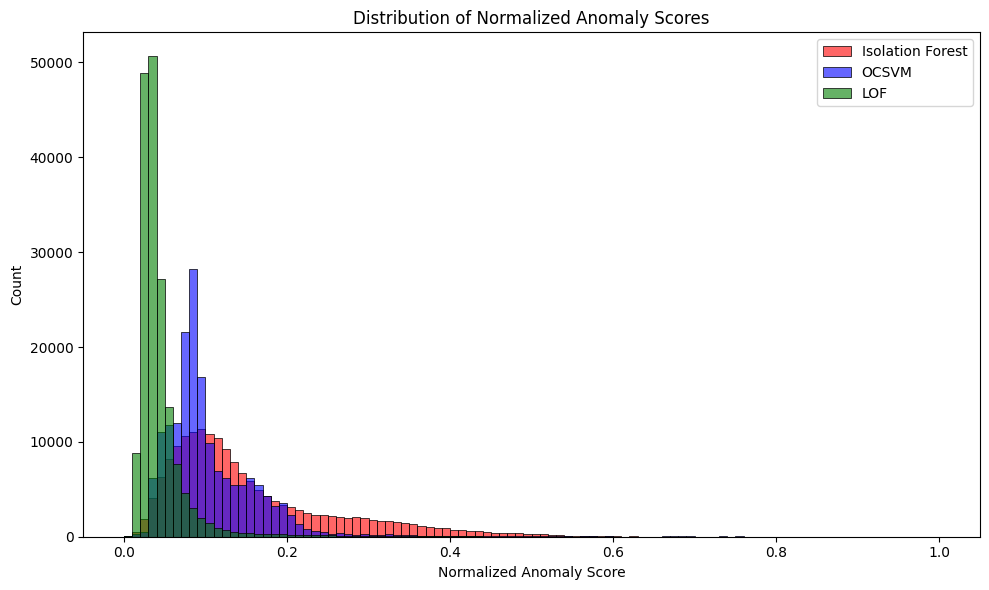

In [25]:
import numpy as np

# Min-max normalize scores for visualization
def normalize_scores(scores):
    return (scores - np.min(scores)) / (np.max(scores) - np.min(scores))

if_norm = normalize_scores(if_scores)
svm_norm = normalize_scores(svm_scores)
lof_norm = normalize_scores(lof_scores)

plt.figure(figsize=(10,6))
sns.histplot(if_norm, bins=100, color='red', label='Isolation Forest', alpha=0.6)
sns.histplot(svm_norm, bins=100, color='blue', label='OCSVM', alpha=0.6)
sns.histplot(lof_norm, bins=100, color='green', label='LOF', alpha=0.6)
plt.xlabel("Normalized Anomaly Score")
plt.ylabel("Count")
plt.title("Distribution of Normalized Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "anomaly_score_distribution.png"), dpi=300)
plt.show()

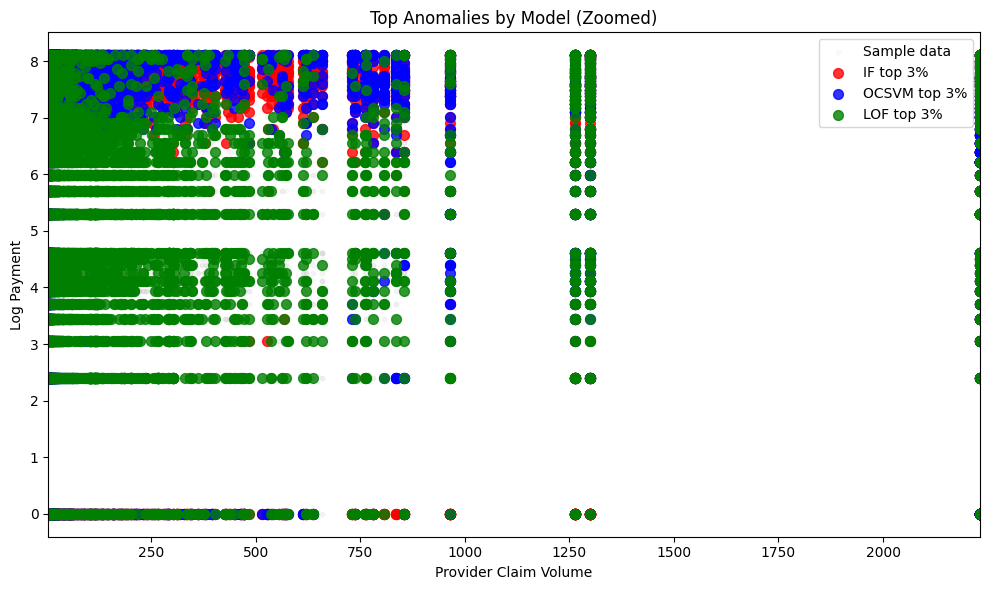

In [57]:
# Sample 10k points for background
X_bg = X.sample(10000, random_state=42)

plt.figure(figsize=(10,6))

# Background points in light grey
plt.scatter(X_bg["provider_claim_volume"], X_bg["log_payment"],
            color='lightgrey', alpha=0.4, s=10, label='Sample data')

# Top anomalies
plt.scatter(top_if["provider_claim_volume"], top_if["log_payment"], 
            color='red', alpha=0.8, s=50, label='IF top 3%')
plt.scatter(top_svm["provider_claim_volume"], top_svm["log_payment"], 
            color='blue', alpha=0.8, s=50, label='OCSVM top 3%')
plt.scatter(top_lof["provider_claim_volume"], top_lof["log_payment"], 
            color='green', alpha=0.8, s=50, label='LOF top 3%')

# Clip x-axis to 1st–99th percentile to avoid extreme spread
x_min, x_max = X["provider_claim_volume"].quantile([0.01, 0.99])
plt.xlim(x_min, x_max)

plt.xlabel("Provider Claim Volume")
plt.ylabel("Log Payment")
plt.title("Top Anomalies by Model (Zoomed)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "top_anomalies_scatter.png"), dpi=300)
plt.show()

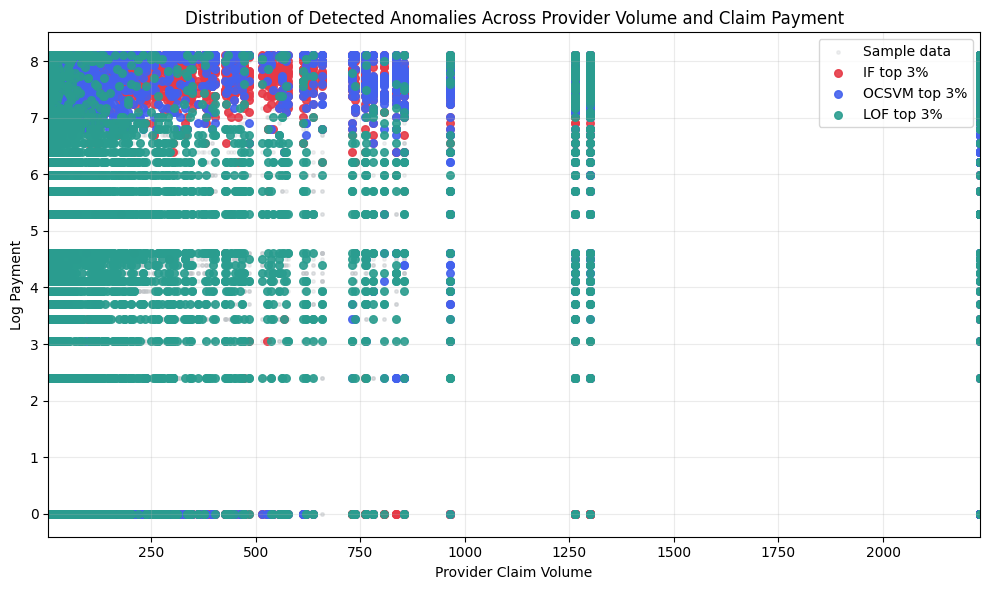

In [59]:
#Plot_Cell: Improved anomaly scatter (Matplotlib)

import os
import matplotlib.pyplot as plt
import seaborn as sns

# nicer color palette
colors = {
    "bg": "#BFC3C7",      # light grey
    "if": "#E63946",      # modern red
    "svm": "#4361EE",     # strong blue
    "lof": "#2A9D8F"      # teal green
}

plt.figure(figsize=(10,6))

# Background sample
plt.scatter(
    X_bg["provider_claim_volume"],
    X_bg["log_payment"],
    color=colors["bg"],
    alpha=0.25,
    s=6,
    label="Sample data"
)

# IF anomalies
plt.scatter(
    top_if["provider_claim_volume"],
    top_if["log_payment"],
    color=colors["if"],
    alpha=0.9,
    s=30,
    label="IF top 3%"
)

# OCSVM anomalies
plt.scatter(
    top_svm["provider_claim_volume"],
    top_svm["log_payment"],
    color=colors["svm"],
    alpha=0.9,
    s=30,
    label="OCSVM top 3%"
)

# LOF anomalies
plt.scatter(
    top_lof["provider_claim_volume"],
    top_lof["log_payment"],
    color=colors["lof"],
    alpha=0.9,
    s=30,
    label="LOF top 3%"
)

# Zoom x-axis to avoid extreme spread
x_min, x_max = X["provider_claim_volume"].quantile([0.01, 0.99])
plt.xlim(x_min, x_max)

# labels and style
plt.xlabel("Provider Claim Volume")
plt.ylabel("Log Payment")
plt.title("Distribution of Detected Anomalies Across Provider Volume and Claim Payment")

plt.grid(alpha=0.25)
plt.legend(frameon=True)

plt.tight_layout()

# save figure
output_path = os.path.join(output_dir, "anomaly_scatter_payment_volume.png")
plt.savefig(output_path, dpi=300)

plt.show()

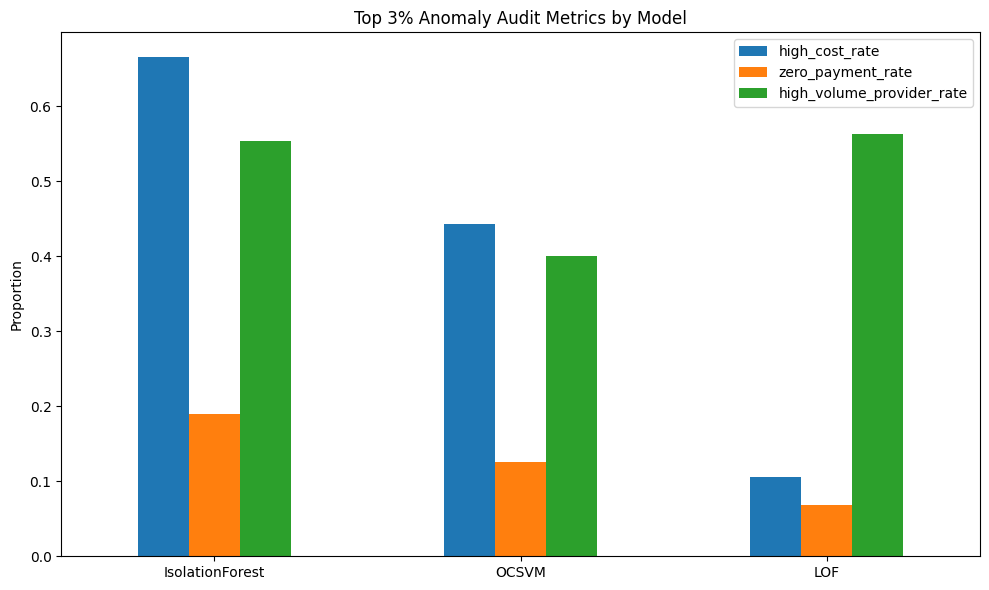

In [27]:
audit_plot = audit_all_df[["high_cost_rate","zero_payment_rate","high_volume_provider_rate"]]
audit_plot.plot(kind='bar', figsize=(10,6))
plt.title("Top 3% Anomaly Audit Metrics by Model")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "audit_metrics_bar.png"), dpi=300)
plt.show()

/tmp/ipykernel_55/3194158843.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="Set2")


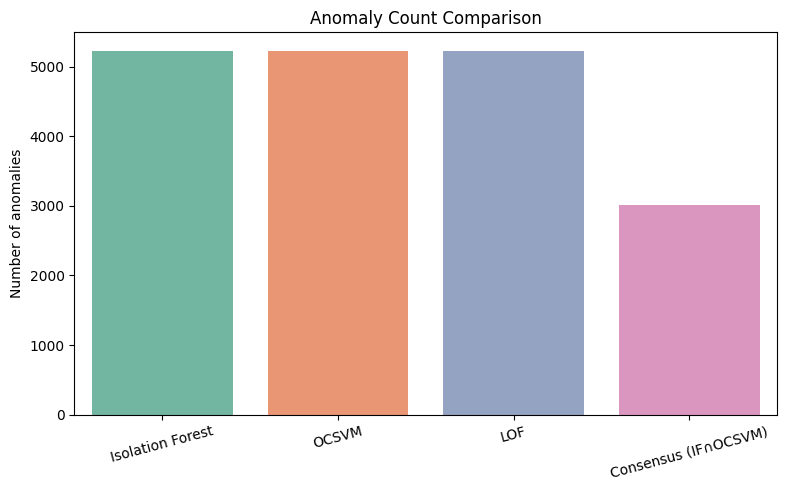

In [30]:
counts = {
    "Isolation Forest": mask_if.sum(),
    "OCSVM": mask_svm.sum(),
    "LOF": mask_lof.sum(),
    "Consensus (IF∩OCSVM)": consensus_mask.sum()
}

plt.figure(figsize=(8,5))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="Set2")
plt.ylabel("Number of anomalies")
plt.title("Anomaly Count Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "anomaly_count_comparison.png"), dpi=300)
plt.show()

In [31]:
import pandas as pd
import numpy as np
from pathlib import Path

# ---------------------------------------------------
# Paths
# ---------------------------------------------------
results_dir = Path("/kaggle/working/thesis_results")

if_file   = results_dir / "top_anomalies_if.csv"
lof_file  = results_dir / "top_anomalies_lof.csv"
svm_file  = results_dir / "top_anomalies_svm.csv"
cons_file = results_dir / "top_anomalies_consensus.csv"


# ---------------------------------------------------
# Helpers
# ---------------------------------------------------
def make_row_keys(df):
    """
    Build a comparable row-level key using all columns.
    This avoids needing a separate ID column.
    """
    df2 = df.copy()
    df2 = df2.reindex(sorted(df2.columns), axis=1)   # stable column order
    row_keys = df2.astype(str).agg("||".join, axis=1)
    return row_keys, set(row_keys)

def load_set(path):
    df = pd.read_csv(path)
    row_keys, row_set = make_row_keys(df)
    return df, row_keys, row_set

def jaccard(a, b):
    if not a and not b:
        return 1.0
    union = a | b
    if len(union) == 0:
        return 0.0
    return len(a & b) / len(union)


# ---------------------------------------------------
# Load exported anomaly sets
# ---------------------------------------------------
if_df, if_keys, if_set = load_set(if_file)
lof_df, lof_keys, lof_set = load_set(lof_file)
svm_df, svm_keys, svm_set = load_set(svm_file)
cons_df, cons_keys, cons_set = load_set(cons_file)

model_sets = {
    "IF": if_set,
    "LOF": lof_set,
    "OCSVM": svm_set,
    "Consensus": cons_set,
}


# ---------------------------------------------------
# 1) Pairwise overlap summary
# ---------------------------------------------------
rows = []
models = list(model_sets.keys())

for i, m1 in enumerate(models):
    for j, m2 in enumerate(models):
        if j <= i:
            continue

        a = model_sets[m1]
        b = model_sets[m2]
        inter = a & b
        union = a | b

        rows.append({
            "model_1": m1,
            "model_2": m2,
            "n_1": len(a),
            "n_2": len(b),
            "intersection": len(inter),
            "union": len(union),
            "jaccard": jaccard(a, b),
            "overlap_pct_of_model_1": len(inter) / len(a) if len(a) else np.nan,
            "overlap_pct_of_model_2": len(inter) / len(b) if len(b) else np.nan,
        })

overlap_summary = pd.DataFrame(rows).sort_values("jaccard", ascending=False)
overlap_summary.to_csv(results_dir / "final_model_overlap_summary.csv", index=False)

print("Saved to:", results_dir / "final_model_overlap_summary.csv")
display(overlap_summary)

Saved to: /kaggle/working/thesis_results/final_model_overlap_summary.csv


,model_1,model_2,n_1,n_2,intersection,union,jaccard,overlap_pct_of_model_1,overlap_pct_of_model_2
5,OCSVM,Consensus,5173,2989,2989,5173,0.577808,0.577808,1.000000
2,IF,Consensus,5196,2989,2989,5196,0.575250,0.575250,1.000000
1,IF,OCSVM,5196,5173,2989,7380,0.405014,0.575250,0.577808
0,IF,LOF,5196,5149,1149,9196,0.124946,0.221132,0.223150
4,LOF,Consensus,5149,2989,744,7394,0.100622,0.144494,0.248913
3,LOF,OCSVM,5149,5173,862,9460,0.091121,0.167411,0.166634


In [32]:
# ---------------------------------------------------
# 2) Jaccard matrix
# ---------------------------------------------------
models = list(model_sets.keys())

jaccard_matrix = pd.DataFrame(index=models, columns=models, dtype=float)

for m1 in models:
    for m2 in models:
        jaccard_matrix.loc[m1, m2] = jaccard(model_sets[m1], model_sets[m2])

jaccard_matrix.to_csv(results_dir / "final_jaccard_matrix.csv")

print("Saved to:", results_dir / "final_jaccard_matrix.csv")
display(jaccard_matrix)

Saved to: /kaggle/working/thesis_results/final_jaccard_matrix.csv


,IF,LOF,OCSVM,Consensus
IF,1.000000,0.124946,0.405014,0.575250
LOF,0.124946,1.000000,0.091121,0.100622
OCSVM,0.405014,0.091121,1.000000,0.577808
Consensus,0.575250,0.100622,0.577808,1.000000


In [33]:
# ---------------------------------------------------
# 3) Claim-level consensus frequency
#    (here: row-level consensus frequency)
# ---------------------------------------------------
all_row_keys = sorted(if_set | lof_set | svm_set)

consensus_rows = []
for key in all_row_keys:
    flagged_by = []
    if key in if_set:
        flagged_by.append("IF")
    if key in lof_set:
        flagged_by.append("LOF")
    if key in svm_set:
        flagged_by.append("OCSVM")

    consensus_rows.append({
        "row_key": key,
        "flag_count": len(flagged_by),
        "flagged_by": ",".join(flagged_by)
    })

consensus_frequency = pd.DataFrame(consensus_rows).sort_values(
    ["flag_count", "flagged_by"], ascending=[False, True]
)

# Summary table: how many rows were flagged by 1, 2, or 3 models
consensus_distribution = (
    consensus_frequency["flag_count"]
    .value_counts()
    .sort_index()
    .rename_axis("flag_count")
    .reset_index(name="n_rows")
)

consensus_frequency.to_csv(results_dir / "final_claim_level_consensus_frequency.csv", index=False)
consensus_distribution.to_csv(results_dir / "final_claim_level_consensus_distribution.csv", index=False)

print("Saved to:", results_dir / "final_claim_level_consensus_frequency.csv")
print("Saved to:", results_dir / "final_claim_level_consensus_distribution.csv")

display(consensus_distribution)
display(consensus_frequency.head(20))

Saved to: /kaggle/working/thesis_results/final_claim_level_consensus_frequency.csv
Saved to: /kaggle/working/thesis_results/final_claim_level_consensus_distribution.csv


,flag_count,n_rows
0,1,7750
1,2,2768
2,3,744


,row_key,flag_count,flagged_by
16,0||-0.2225209339563143||0.9749279121818236||0|...,3,"IF,LOF,OCSVM"
18,0||-0.2225209339563143||0.9749279121818236||0|...,3,"IF,LOF,OCSVM"
19,0||-0.2225209339563143||0.9749279121818236||0|...,3,"IF,LOF,OCSVM"
34,0||-0.2225209339563143||0.9749279121818236||0|...,3,"IF,LOF,OCSVM"
47,0||-0.2225209339563143||0.9749279121818236||0|...,3,"IF,LOF,OCSVM"
97,0||-0.2225209339563143||0.9749279121818236||0|...,3,"IF,LOF,OCSVM"
252,0||-0.2225209339563143||0.9749279121818236||1|...,3,"IF,LOF,OCSVM"
259,0||-0.2225209339563143||0.9749279121818236||1|...,3,"IF,LOF,OCSVM"
261,0||-0.2225209339563143||0.9749279121818236||1|...,3,"IF,LOF,OCSVM"
262,0||-0.2225209339563143||0.9749279121818236||1|...,3,"IF,LOF,OCSVM"


In [34]:
# ---------------------------------------------------
# 4) Optional: score correlation on shared rows
# ---------------------------------------------------
def find_score_col(df):
    candidates = ["anomaly_score", "score", "decision_score", "outlier_score"]
    for c in candidates:
        if c in df.columns:
            return c
    return None

score_col_if = find_score_col(if_df)
score_col_lof = find_score_col(lof_df)
score_col_svm = find_score_col(svm_df)

score_corr_rows = []

def build_row_key_excluding_score(df, score_col):
    """
    Create a stable row key from all non-score columns.
    This lets us align the same exported row across model outputs.
    """
    cols = [c for c in df.columns if c != score_col]
    df2 = df[cols].copy()
    df2 = df2.reindex(sorted(df2.columns), axis=1)
    return df2.astype(str).agg("||".join, axis=1)

def shared_score_corr(df1, df2, model1, model2, score1, score2):
    if score1 is None or score2 is None:
        return {
            "model_1": model1,
            "model_2": model2,
            "score_col_1": score1,
            "score_col_2": score2,
            "n_shared": 0,
            "pearson_corr": np.nan,
            "spearman_corr": np.nan,
            "note": "score column missing in one or both files"
        }

    a = df1.copy()
    b = df2.copy()

    a["row_key"] = build_row_key_excluding_score(a, score1)
    b["row_key"] = build_row_key_excluding_score(b, score2)

    a = a[["row_key", score1]].rename(columns={score1: f"{model1}_score"})
    b = b[["row_key", score2]].rename(columns={score2: f"{model2}_score"})

    # if duplicate row_keys exist, average score within each file
    a = a.groupby("row_key", as_index=False)[f"{model1}_score"].mean()
    b = b.groupby("row_key", as_index=False)[f"{model2}_score"].mean()

    merged = a.merge(b, on="row_key", how="inner")

    if len(merged) < 3:
        return {
            "model_1": model1,
            "model_2": model2,
            "score_col_1": score1,
            "score_col_2": score2,
            "n_shared": len(merged),
            "pearson_corr": np.nan,
            "spearman_corr": np.nan,
            "note": "fewer than 3 shared rows"
        }

    return {
        "model_1": model1,
        "model_2": model2,
        "score_col_1": score1,
        "score_col_2": score2,
        "n_shared": len(merged),
        "pearson_corr": merged[f"{model1}_score"].corr(merged[f"{model2}_score"], method="pearson"),
        "spearman_corr": merged[f"{model1}_score"].corr(merged[f"{model2}_score"], method="spearman"),
        "note": ""
    }

pairs = [
    (if_df, lof_df, "IF", "LOF", score_col_if, score_col_lof),
    (if_df, svm_df, "IF", "OCSVM", score_col_if, score_col_svm),
    (lof_df, svm_df, "LOF", "OCSVM", score_col_lof, score_col_svm),
]

for args in pairs:
    result = shared_score_corr(*args)
    score_corr_rows.append(result)

score_corr_df = pd.DataFrame(score_corr_rows)
score_corr_df.to_csv(results_dir / "final_model_score_correlations.csv", index=False)

print("Saved to:", results_dir / "final_model_score_correlations.csv")
display(score_corr_df)

Saved to: /kaggle/working/thesis_results/final_model_score_correlations.csv


,model_1,model_2,score_col_1,score_col_2,n_shared,pearson_corr,spearman_corr,note
0,IF,LOF,None,None,0,NaN,NaN,score column missing in one or both files
1,IF,OCSVM,None,None,0,NaN,NaN,score column missing in one or both files
2,LOF,OCSVM,None,None,0,NaN,NaN,score column missing in one or both files


In [38]:
import pandas as pd
import numpy as np
from pathlib import Path

# ---------------------------------------------------
# 5) Audit summary
# ---------------------------------------------------
results_dir = Path("/kaggle/working/thesis_results")
audit_file = results_dir / "audit_stats.csv"

audit_df = pd.read_csv(audit_file)

print("Audit stats shape:", audit_df.shape)
display(audit_df.head())

numeric_cols = audit_df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) == 0:
    print("No numeric columns found in audit_stats.csv")
    audit_summary = pd.DataFrame()
else:
    desc = audit_df[numeric_cols].describe().T
    desc["missing_count"] = audit_df[numeric_cols].isna().sum()
    desc["missing_pct"] = audit_df[numeric_cols].isna().mean() * 100

    audit_summary = desc.reset_index().rename(columns={"index": "metric"})

audit_summary.to_csv(results_dir / "audit_summary_extended.csv", index=False)

print("Saved to:", results_dir / "audit_summary_extended.csv")
display(audit_summary)

Audit stats shape: (3, 6)


,Unnamed: 0,high_cost_rate,zero_payment_rate,high_volume_provider_rate,avg_log_payment,count
0,IsolationForest,0.664946,0.189794,0.553899,6.085417,5232
1,OCSVM,0.443043,0.125956,0.400038,5.781798,5232
2,LOF,0.106269,0.068043,0.562118,4.839758,5232


Saved to: /kaggle/working/thesis_results/audit_summary_extended.csv


,metric,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct
0,high_cost_rate,3.0,0.404753,0.281300,0.106269,0.274656,0.443043,0.553995,0.664946,0,0.0
1,zero_payment_rate,3.0,0.127931,0.060899,0.068043,0.096999,0.125956,0.157875,0.189794,0,0.0
2,high_volume_provider_rate,3.0,0.505352,0.091297,0.400038,0.476969,0.553899,0.558008,0.562118,0,0.0
3,avg_log_payment,3.0,5.568991,0.649524,4.839758,5.310778,5.781798,5.933607,6.085417,0,0.0
4,count,3.0,5232.000000,0.000000,5232.000000,5232.000000,5232.000000,5232.000000,5232.000000,0,0.0


In [42]:
#Cell_A: setup for graphs
import pandas as pd
import numpy as np
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go

results_dir = Path("/kaggle/working/thesis_results")

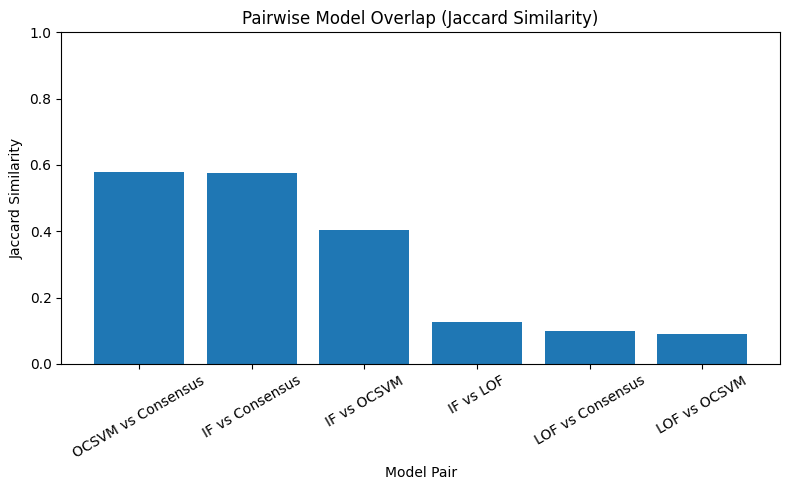

In [48]:
#Plot_Cell1: Pairwise Model Overlap (Jaccard Similarity)

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("/kaggle/working/thesis_results")

overlap_summary = pd.read_csv(results_dir / "final_model_overlap_summary.csv")
overlap_summary["pair"] = overlap_summary["model_1"] + " vs " + overlap_summary["model_2"]

plt.figure(figsize=(8,5))
plt.bar(overlap_summary["pair"], overlap_summary["jaccard"])
plt.title("Pairwise Model Overlap (Jaccard Similarity)")
plt.xlabel("Model Pair")
plt.ylabel("Jaccard Similarity")
plt.ylim(0,1)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

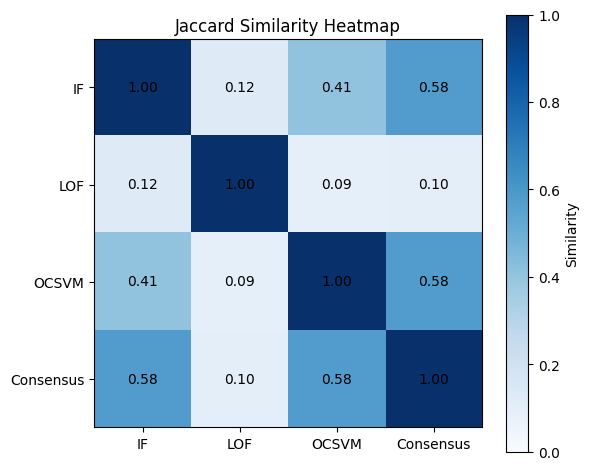

In [49]:
#Plot_Cell2: Jaccard Similarity Heatmap

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("/kaggle/working/thesis_results")

jaccard_matrix = pd.read_csv(results_dir / "final_jaccard_matrix.csv", index_col=0)

plt.figure(figsize=(6,5))
plt.imshow(jaccard_matrix, cmap="Blues", vmin=0, vmax=1)

plt.xticks(range(len(jaccard_matrix.columns)), jaccard_matrix.columns)
plt.yticks(range(len(jaccard_matrix.index)), jaccard_matrix.index)

for i in range(len(jaccard_matrix)):
    for j in range(len(jaccard_matrix)):
        plt.text(j, i, f"{jaccard_matrix.iloc[i,j]:.2f}", ha="center", va="center")

plt.title("Jaccard Similarity Heatmap")
plt.colorbar(label="Similarity")
plt.tight_layout()
plt.show()

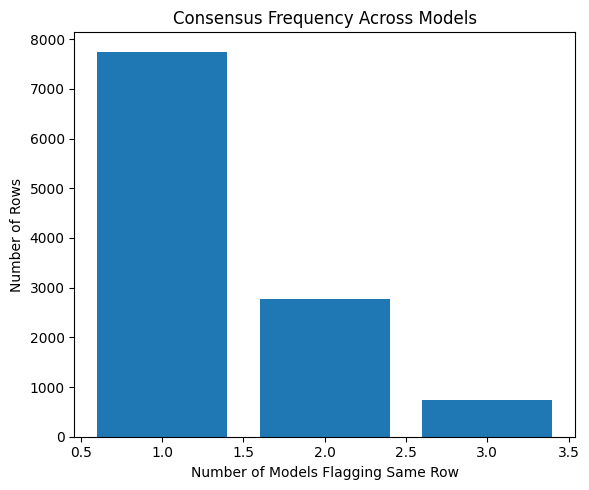

In [50]:
#Plot_Cell3: Consensus Frequency Distribution

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("/kaggle/working/thesis_results")

consensus = pd.read_csv(results_dir / "final_claim_level_consensus_distribution.csv")

plt.figure(figsize=(6,5))
plt.bar(consensus["flag_count"], consensus["n_rows"])

plt.title("Consensus Frequency Across Models")
plt.xlabel("Number of Models Flagging Same Row")
plt.ylabel("Number of Rows")

plt.tight_layout()
plt.show()

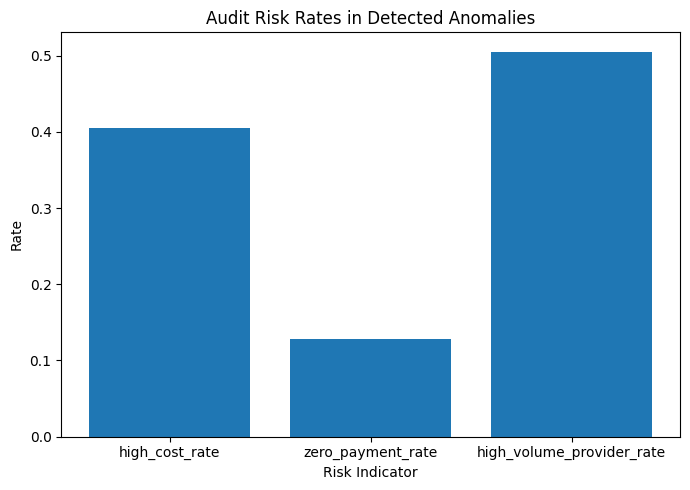

In [54]:
#Plot_Cell5_Fix: Audit Risk Rates (without count)

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("/kaggle/working/thesis_results")

audit_summary = pd.read_csv(results_dir / "audit_summary_extended.csv")

risk_metrics = audit_summary[
    audit_summary["metric"].isin([
        "high_cost_rate",
        "zero_payment_rate",
        "high_volume_provider_rate"
    ])
]

plt.figure(figsize=(7,5))
plt.bar(risk_metrics["metric"], risk_metrics["mean"])

plt.title("Audit Risk Rates in Detected Anomalies")
plt.xlabel("Risk Indicator")
plt.ylabel("Rate")

plt.tight_layout()
plt.show()

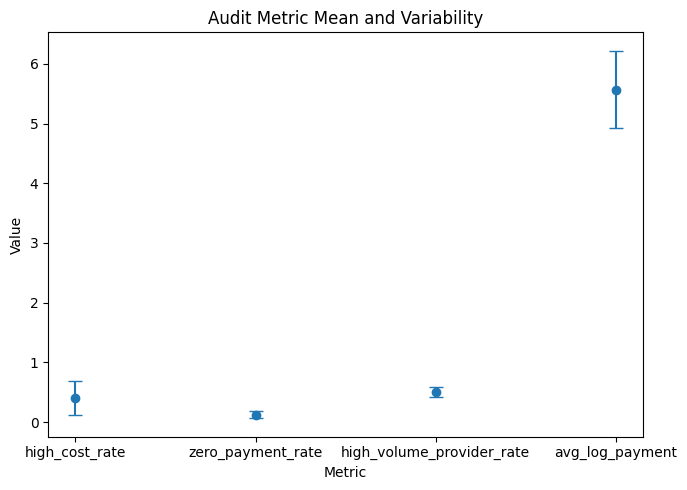

In [55]:
#Plot_Cell5_Alt: Audit Metric Range

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

results_dir = Path("/kaggle/working/thesis_results")

audit_summary = pd.read_csv(results_dir / "audit_summary_extended.csv")

audit_plot = audit_summary[audit_summary["metric"] != "count"]

plt.figure(figsize=(7,5))

plt.errorbar(
    audit_plot["metric"],
    audit_plot["mean"],
    yerr=audit_plot["std"],
    fmt='o',
    capsize=5
)

plt.title("Audit Metric Mean and Variability")
plt.xlabel("Metric")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

In [43]:
import shutil

# Path to your results folder
folder_to_zip = "/kaggle/working/thesis_results"
zip_path = "/kaggle/working/thesis_results.zip"

# Create zip
shutil.make_archive(zip_path.replace(".zip",""), 'zip', folder_to_zip)
print("Folder zipped at:", zip_path)

Folder zipped at: /kaggle/working/thesis_results.zip
